# Iris EDA Mini Project — Unit I: Foundation of Data and Analysis

## Day 1: Load Dataset & Explore Structure

In [2]:
import pandas as pd

df = pd.read_csv("../data/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows: 3


**Scale of measurement:**

| Variable | Scale | Reason |
|---|---|---|
| species | Nominal | categories, no order |
| sepal_length | Ratio | true zero, meaningful ratios |
| sepal_width | Ratio | true zero, meaningful ratios |
| petal_length | Ratio | true zero, meaningful ratios |
| petal_width | Ratio | true zero, meaningful ratios |

## Day 2: Measures of Central Tendency

In [5]:
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

central_tendency = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0]
})
central_tendency.round(2)

,Mean,Median,Mode
sepal_length,5.84,5.80,5.0
sepal_width,3.05,3.00,3.0
petal_length,3.76,4.35,1.5
petal_width,1.20,1.30,0.2


In [6]:
print("Most common species (mode):", df["species"].mode()[0])
df["species"].value_counts()

Most common species (mode): setosa


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## Day 3: Dispersion & Five-Number Summary


In [7]:
dispersion = pd.DataFrame({
    "Range": df[numeric_cols].max() - df[numeric_cols].min(),
    "Variance": df[numeric_cols].var(),
    "Std_Dev": df[numeric_cols].std(),
    "IQR": df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
})
dispersion.round(2)
    

,Range,Variance,Std_Dev,IQR
sepal_length,3.6,0.69,0.83,1.3
sepal_width,2.4,0.19,0.43,0.5
petal_length,5.9,3.11,1.76,3.5
petal_width,2.4,0.58,0.76,1.5


In [8]:
five_num = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T[["min", "25%", "50%", "75%", "max"]]
five_num.columns = ["Min", "Q1", "Median", "Q3", "Max"]
five_num.round(2)


,Min,Q1,Median,Q3,Max
sepal_length,4.3,5.1,5.80,6.4,7.9
sepal_width,2.0,2.8,3.00,3.3,4.4
petal_length,1.0,1.6,4.35,5.1,6.9
petal_width,0.1,0.3,1.30,1.8,2.5


## Day 4: Visualizations — Histograms, Box Plots, Species Frequency

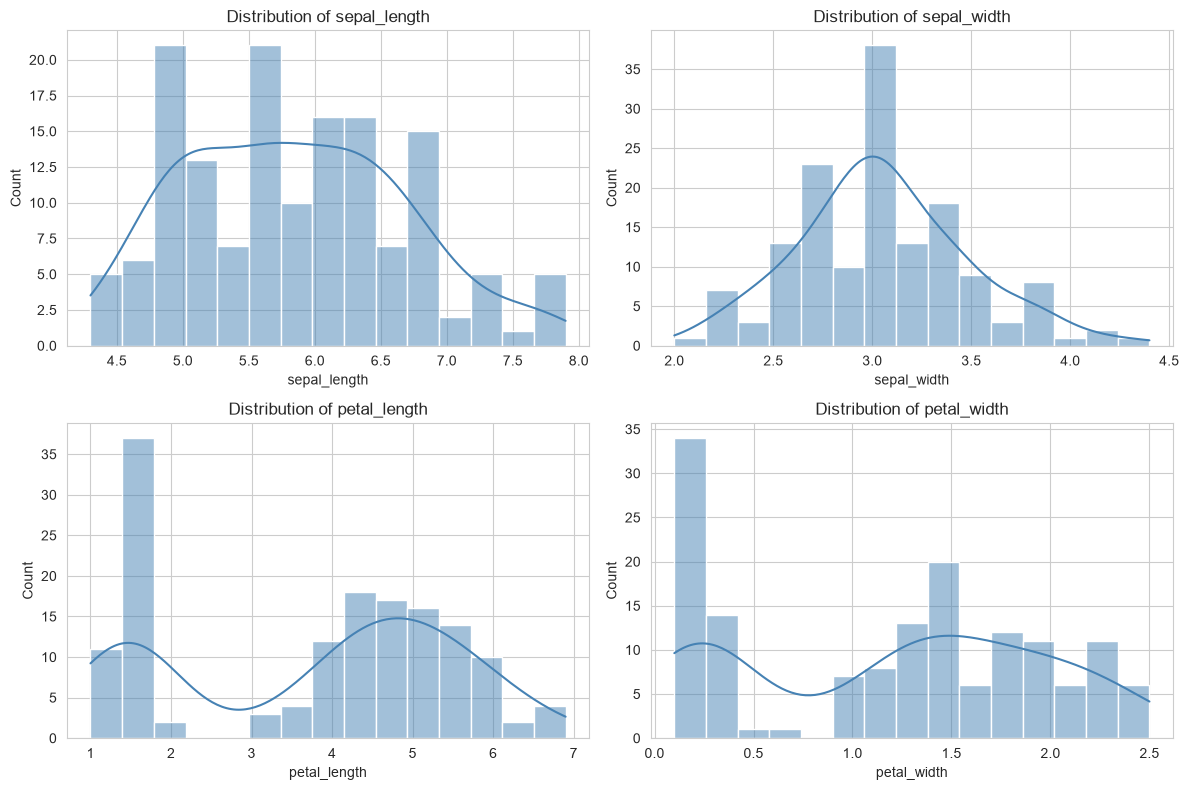

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], bins=15, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("../outputs/histograms.png", dpi=120)
plt.show()

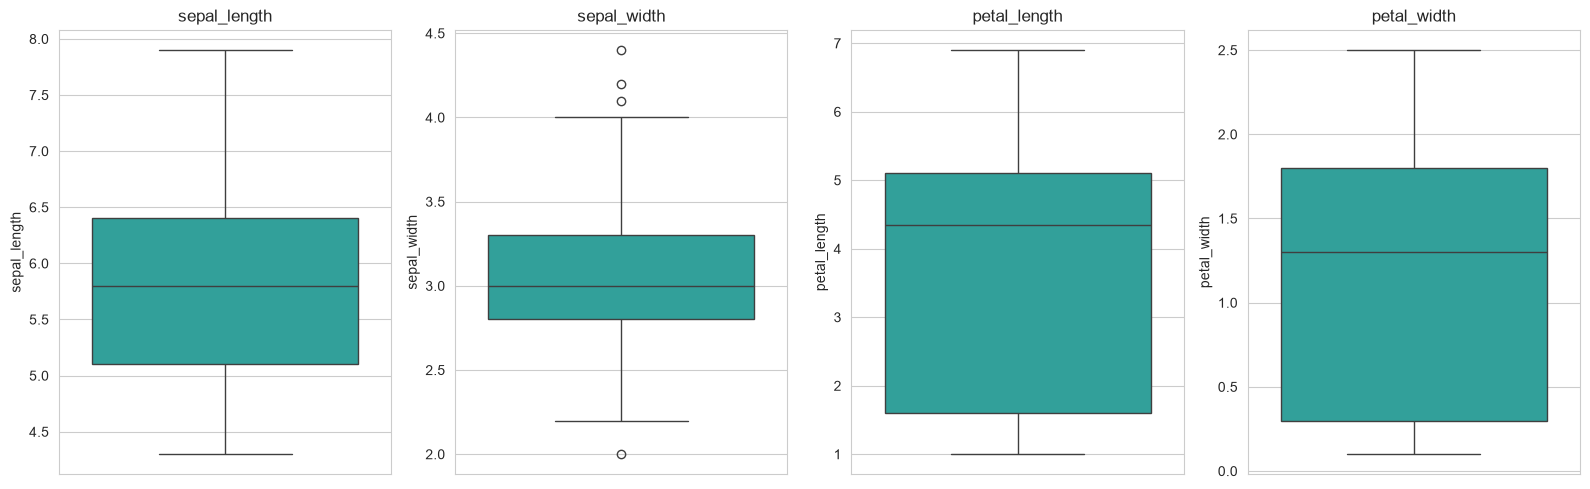

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightseagreen")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../outputs/boxplots.png", dpi=120)
plt.show()

C:\Users\D.NIKITHA\AppData\Local\Temp\ipykernel_22840\1881379021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=species_freq.index, y=species_freq.values, palette="viridis")


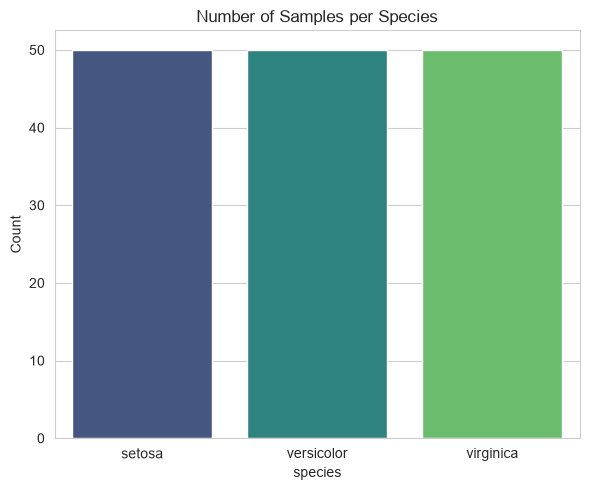

In [11]:
species_freq = df["species"].value_counts()
plt.figure(figsize=(6, 5))
sns.barplot(x=species_freq.index, y=species_freq.values, palette="viridis")
plt.title("Number of Samples per Species")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/species_bar_chart.png", dpi=120)
plt.show()

## Day 5: Distribution Shape & Outlier Detection

In [12]:
from scipy import stats

shape_stats = pd.DataFrame({
    "Skewness": df[numeric_cols].apply(lambda x: stats.skew(x)),
    "Kurtosis": df[numeric_cols].apply(lambda x: stats.kurtosis(x))
})
shape_stats.round(2)

,Skewness,Kurtosis
sepal_length,0.31,-0.57
sepal_width,0.33,0.24
petal_length,-0.27,-1.40
petal_width,-0.10,-1.34


In [13]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

for col in numeric_cols:
    out = iqr_outliers(df[col])
    print(f"{col}: {len(out)} outlier(s) -> {out.tolist()}")

sepal_length: 0 outlier(s) -> []
sepal_width: 4 outlier(s) -> [4.4, 4.1, 4.2, 2.0]
petal_length: 0 outlier(s) -> []
petal_width: 0 outlier(s) -> []


In [14]:
z_scores = df[numeric_cols].apply(stats.zscore)
z_outliers = (z_scores.abs() > 3).sum()
print("Z-score-based outliers (|z| > 3) per column:")
print(z_outliers)

Z-score-based outliers (|z| > 3) per column:
sepal_length    0
sepal_width     1
petal_length    0
petal_width     0
dtype: int64


## Day 6: Relationships Between Variables & Summary

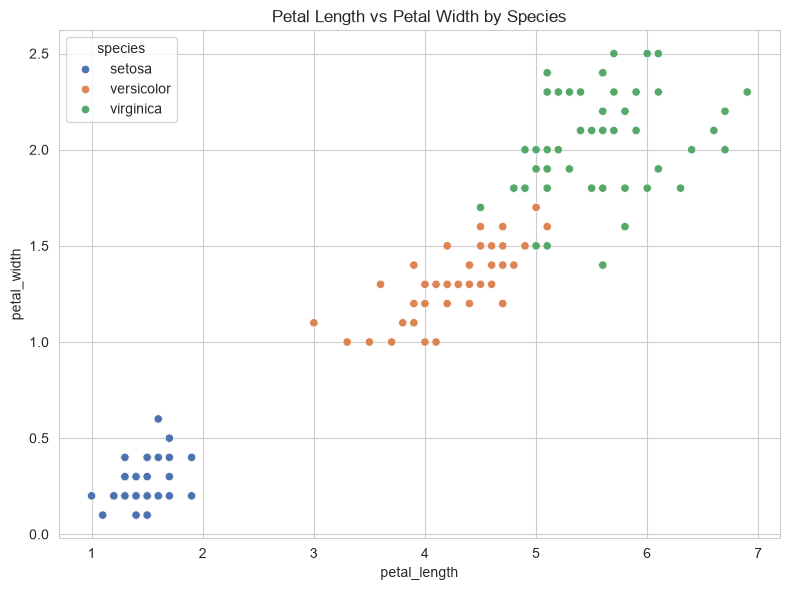

Correlation (petal_length vs petal_width): 0.96


In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", palette="deep")
plt.title("Petal Length vs Petal Width by Species")
plt.tight_layout()
plt.savefig("../outputs/scatter_petal.png", dpi=120)
plt.show()

corr = df["petal_length"].corr(df["petal_width"])
print(f"Correlation (petal_length vs petal_width): {corr:.2f}")

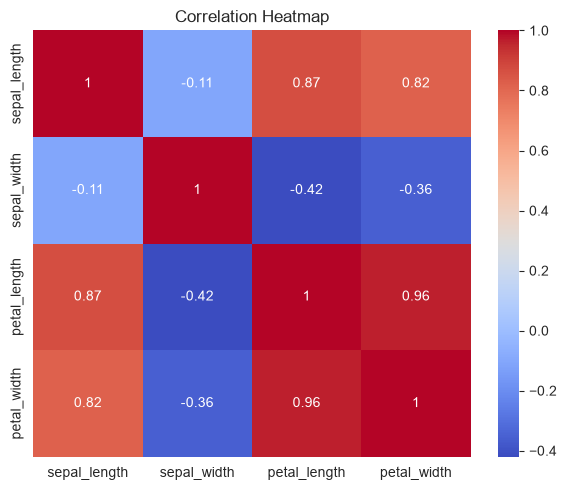

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=120)
plt.show()

C:\Users\D.NIKITHA\AppData\Local\Temp\ipykernel_22840\2491210133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y="sepal_length", palette="Set2")


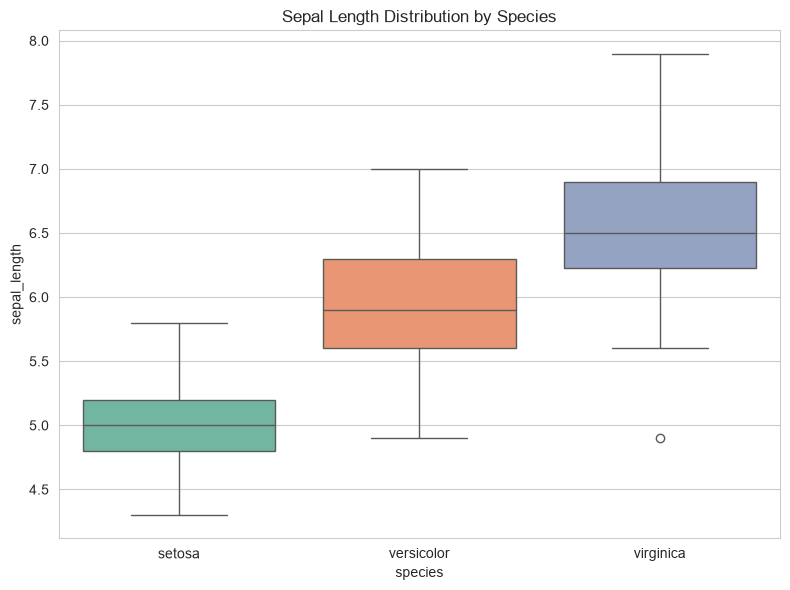

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="species", y="sepal_length", palette="Set2")
plt.title("Sepal Length Distribution by Species")
plt.tight_layout()
plt.savefig("../outputs/boxplot_by_species.png", dpi=120)
plt.show()